In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(1)

In [89]:
def generate_pla_data(n_samples=100, random_state=42):
    """
    Tạo dữ liệu 2D có thể phân tách tuyến tính (linearly separable) cho PLA.
    """
    # Tạo 2 cụm dữ liệu phân biệt rõ ràng (centers=2)
    X, y = make_blobs(n_samples=n_samples, 
                      centers=2, 
                      cluster_std=2.3,
                      random_state=random_state)
    # Đổi nhãn từ {0, 1} sang {-1, 1} cho thuật toán Perceptron
    y = np.where(y == 0, -1, 1)
    return X, y

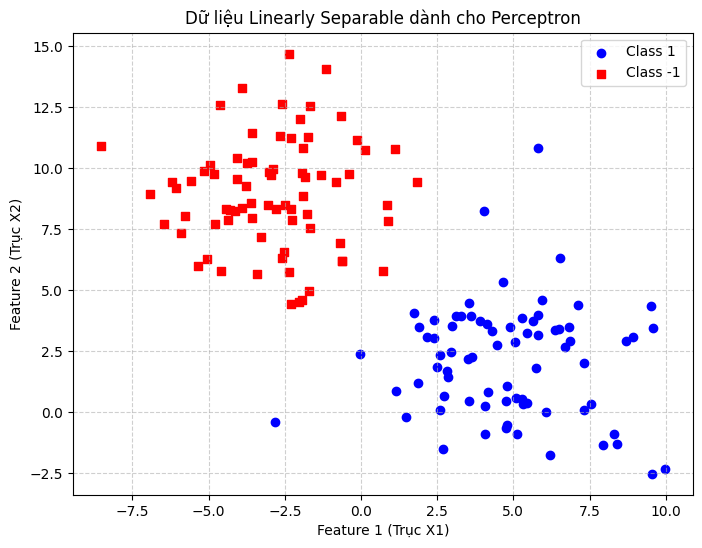

In [90]:
X, y = generate_pla_data(n_samples=150)
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', marker='o', label='Class 1')
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', marker='s', label='Class -1')
plt.title("Dữ liệu Linearly Separable dành cho Perceptron")
plt.xlabel("Feature 1 (Trục X1)")
plt.ylabel("Feature 2 (Trục X2)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Init parameters

In [91]:
N_0, d_0 = X.shape
X_bar = np.c_[np.ones((N_0, 1)), X]
N, d = X_bar.shape
w = np.random.randn(d)
w

array([ 1.62434536, -0.61175641, -0.52817175])

In [92]:
def compute_label(W, x):
    return np.sign(np.dot(W.T, x))
def predict(W, X):
    return np.sign(np.dot(X, W))
def has_converged(X, y, W):     
    return np.array_equal(predict(W, X), y) 
def perceptron_learning(W_init, X, y, max_iters=50):
    W = [W_init] 
    it = 0
    N = X.shape[0]
    while True:
        indices = np.random.permutation(N)
        for i in indices:
            label = compute_label(W[-1], X[i])
            if label != y[i]:
                W_new = W[-1] + y[i] * X[i]
                W.append(W_new)
        it += 1
        if has_converged(X, y, W[-1]) or it == max_iters:
            break
    return W

In [93]:
W_history = perceptron_learning(w, X_bar, y)
W_history

[array([ 1.62434536, -0.61175641, -0.52817175]),
 array([2.62434536, 5.8977053 , 2.89314427]),
 array([ 1.62434536,  8.5725262 , -8.42926753]),
 array([ 2.62434536, 11.69029617, -4.49550117]),
 array([ 3.62434536,  8.87526012, -4.87842306]),
 array([ 4.62434536, 10.61510586, -0.7941709 ]),
 array([ 3.62434536,  9.75331132, -9.28917154]),
 array([ 4.62434536, 13.30774686, -4.81141548]),
 array([ 5.62434536, 13.28979775, -2.40940087]),
 array([ 4.62434536, 12.57256846, -8.19942956]),
 array([ 5.62434536, 16.60373658,  0.03012921]),
 array([ 4.62434536, 15.74194203, -8.46487143]),
 array([ 5.62434536, 15.72399292, -6.06285682]),
 array([ 6.62434536, 12.90895687, -6.44577871]),
 array([ 7.62434536, 12.89100776, -4.0437641 ]),
 array([ 8.62434536, 10.07597171, -4.42668599]),
 array([ 9.62434536,  7.26093567, -4.80960788]),
 array([10.62434536,  7.24298655, -2.40759328]),
 array([  9.62434536,   5.4139566 , -11.82340837]),
 array([10.62434536, 11.21530618, -7.85900174]),
 array([11.62434536,

In [94]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

def plot_final_boundary(X, y, w_final):
    plt.figure(figsize=(8, 6))
    
    # Vẽ các điểm dữ liệu
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', marker='o', label='Class 1')
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', marker='s', label='Class -1')
    
    # Tính toán tọa độ đường thẳng
    # Lấy min và max của trục X1 để tạo 2 điểm đầu mút cho đường thẳng
    x1_min, x1_max = np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1
    
    # Công thức: x2 = -(w0 + w1*x1) / w2
    # w_final[0] là bias, w_final[1] là w1, w_final[2] là w2
    x2_min = -(w_final[0] + w_final[1] * x1_min) / w_final[2]
    x2_max = -(w_final[0] + w_final[1] * x1_max) / w_final[2]
    
    # Vẽ đường thẳng
    plt.plot([x1_min, x1_max], [x2_min, x2_max], color='green', linewidth=2, label='Decision Boundary')
    
    plt.title("Kết quả cuối cùng của Perceptron")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(np.min(X[:, 0]) - 1.5, np.max(X[:, 0]) + 1.5)
    plt.ylim(np.min(X[:, 1]) - 1.5, np.max(X[:, 1]) + 1.5)
    plt.show()

def create_pla_animation(X, y, W_history):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Vẽ điểm dữ liệu nền
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', marker='o', label='Class 1')
    ax.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', marker='s', label='Class -1')
    
    # Giới hạn trục tọa độ để khung hình không bị giật khi đường thẳng di chuyển
    x1_min, x1_max = np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1
    ax.set_xlim(x1_min - 0.5, x1_max + 0.5)
    ax.set_ylim(np.min(X[:, 1]) - 1.5, np.max(X[:, 1]) + 1.5)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    
    # Khởi tạo đối tượng đường thẳng rỗng
    line, = ax.plot([], [], color='green', linewidth=2)
    title = ax.set_title("Perceptron Learning Algorithm - Init")

    def init():
        line.set_data([], [])
        return line, title

    # Hàm cập nhật frame
    def update(frame):
        w = W_history[frame]
        
        # Nếu w[2] == 0 (tránh lỗi chia cho 0 ở những bước đầu)
        if w[2] == 0:
            x2_min, x2_max = 0, 0
        else:
            x2_min = -(w[0] + w[1] * x1_min) / w[2]
            x2_max = -(w[0] + w[1] * x1_max) / w[2]
            
        line.set_data([x1_min, x1_max], [x2_min, x2_max])
        title.set_text(f"Perceptron Update - Lần lặp thứ {frame}")
        return line, title

    # Tạo animation
    anim = FuncAnimation(fig, update, frames=len(W_history), init_func=init, blit=True, interval=200)
    
    # Đóng hình thừa để không in ra 2 biểu đồ
    plt.close() 
    
    # Trả về đối tượng HTML để Jupyter Notebook có thể hiển thị như một video
    return HTML(anim.to_jshtml())

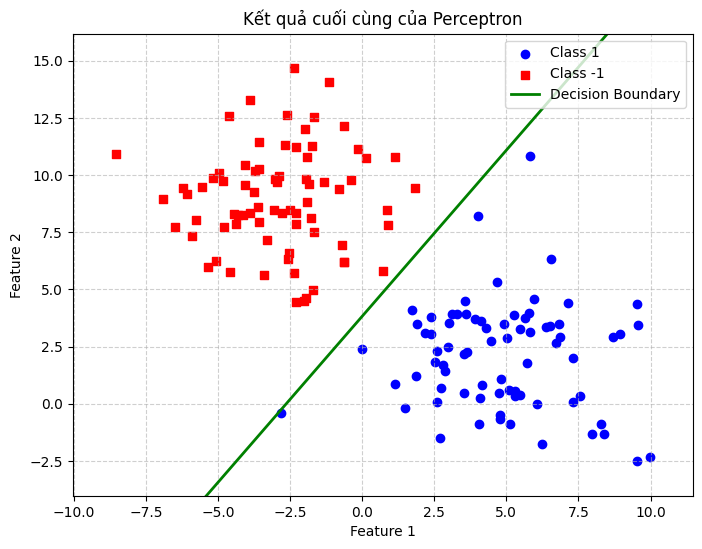

In [95]:
plot_final_boundary(X, y, W_history[-1])

In [96]:
create_pla_animation(X, y, W_history)